# Logo TripletNet Retrieval

## Import Libraries

In [2]:
!pip install datasets==3.6.0 --no-warn-conflicts --quiet
!pip install faiss-cpu==1.11.0 --no-warn-conflicts --quiet

import os
from pathlib import Path
import json
import datasets
from datasets import load_dataset
import faiss
from copy import deepcopy
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
import torch
from PIL import Image
from io import BytesIO
import requests
import torchvision
import matplotlib.pyplot as plt
from typing import Union, List,Any

torch.set_grad_enabled(False)

import warnings
warnings.filterwarnings('ignore')

## Configuration

In [ ]:
class Config:
    """
    Configuration for logo retrieval using TripletNet.
    """
    # ========== Base Paths ==========
    project_name = "logo_recognition_similarity_search_project"
    base_dir = Path("/content/drive/MyDrive")/project_name
    output_dir = base_dir / "output"
    cache_dir = base_dir / "cache"
    evaluate_dir = output_dir / "evaluation_results"

    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(cache_dir, exist_ok=True)

    # ========== Dataset and embeddings ==========
    dataset_with_embeddings_path = "mlproject5606/Logo-Recognition-ResNet50-TripletNet-Embeddings-Dataset"
    dataset_with_embeddings_cache_dir = cache_dir / dataset_with_embeddings_path.split("/")[-1]
    faiss_index_column = "tripletnet_embedding"

    # ========== Runtime ==========
    device = "cuda" if torch.cuda.is_available() else "cpu"
    num_workers = 4 if os.cpu_count()>=4 else 0
    seed = 42

    # ========== Model ==========
    model_path = 'mlproject5606/Logo-Recognition-ResNet50-TripletNet-Retrieval'
    input_dim = 2048
    embed_dim = 256

    # ========== Retrieval parameters ==========
    top_ks = 5


# Create Configuration Object
cfg = Config()

## Evaluate Recall@K

In [ ]:
pd.read_csv(f"{cfg.evaluate_dir}/evaluate_recall_at_ks.csv")

,k,recall_category,recall_resnet50
0,1,0.250386,0.782033
1,5,0.531460,0.963969
2,10,0.587415,0.985595


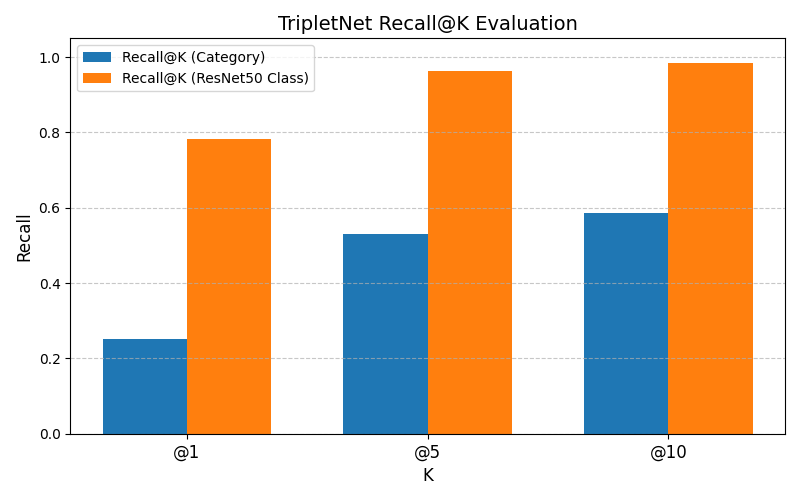

In [ ]:
Image.open(f"{cfg.evaluate_dir}/evaluate_recall_at_ks.png")

## Load Dataset with Indexed Embeddings

In [ ]:

ds_with_embeddings = load_dataset(
    path = cfg.dataset_with_embeddings_path,
    cache_dir = cfg.dataset_with_embeddings_cache_dir,
    )

ds_train_with_embeddings = ds_with_embeddings['train']
ds_test_with_embeddings = ds_with_embeddings['test']
ds_train_with_embeddings, ds_test_with_embeddings

README.md:   0%|          | 0.00/821 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/90 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/90 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/90 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/20 [00:00<?, ?it/s]

(Dataset({
     features: ['id', 'path', 'path_category', 'prompt', 'image', 'resnet50_embedding', 'tripletnet_embedding', 'category', 'resnet50_class'],
     num_rows: 1458113
 }),
 Dataset({
     features: ['id', 'path', 'path_category', 'prompt', 'image', 'resnet50_embedding', 'tripletnet_embedding', 'category', 'resnet50_class'],
     num_rows: 319471
 }))

## Load Pretrained TripletNet Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torchvision.transforms import Compose
from typing import List, Union, Optional, Dict
from PIL import Image
from huggingface_hub import hf_hub_download
import joblib

class GenericBackbone(nn.Module):
    def __init__(
        self,
        model: nn.Module,
        weights_meta: dict,
        transform: Compose,
        freeze: bool = True,
        return_layers: Optional[List[str]] = None,
        remove_layers: Optional[List[str]] = None,
        device: Optional[torch.device] = None,
    ):
        """
        Generic backbone wrapper for torchvision vision models.

        Args:
            model: Torchvision model (e.g., resnet50).
            weights_meta: Metadata from the weights object.
            transform: Recommended transform for input preprocessing.
            freeze: Whether to freeze model weights (default: True).
            return_layers: List of intermediate layers to capture via hooks.
            remove_layers: List of layer names to remove from model (e.g. ["fc"]).
            device: Device to use.
        """
        super().__init__()
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.transform = transform
        self.weights_meta = weights_meta
        self.return_layers = return_layers or []
        self.remove_layers = remove_layers or []


        # Apply remove_layers dynamically
        for layer_name in self.remove_layers:
            if hasattr(model, layer_name):
                setattr(model, layer_name, nn.Identity())

        self.model = model.to(self.device).eval()

        if freeze:
            for param in self.model.parameters():
                param.requires_grad = False

        # Prepare storage for hook outputs
        self._outputs: Dict[str, torch.Tensor] = {}
        self._register_hooks()

    def _register_hooks(self):
        """
        Register forward hooks for layers specified in return_layers.
        """
        for name, module in self.model.named_modules():
            if name in self.return_layers:
                module.register_forward_hook(self._get_hook(name))

    def _get_hook(self, name: str):
        def hook(module, input, output):
            self._outputs[name] = output.detach().cpu()
        return hook

    def _prepare_input(self, images: Union[Image.Image, List[Image.Image]]) -> torch.Tensor:
        """
        Transform PIL image(s) and prepare a batch tensor.
        """
        if isinstance(images, Image.Image):
            images = [images]
        return torch.stack([self.transform(img) for img in images]).to(self.device)


    def _get_last_valid_layer_name(self) -> Optional[str]:
        """
        Return the name of the last non-Identity layer in the model.
        """
        for name, module in reversed(list(self.model.named_modules())):
            if not isinstance(module, nn.Identity):
                return name
        return None


    def forward(self,images: Union[Image.Image, List[Image.Image]]) -> Dict[str, torch.Tensor]:
        """
        Forward pass through the model.

        Returns:
            - If return_layers are set: returns a dict of requested layer outputs.
            - If return_layers is empty: returns dict with model output under key <final_layer_name>.
        """
        self._outputs = {}

        try:
            x = self._prepare_input(images)

            with torch.no_grad():
                output = self.model(x).cpu()

            if not self.return_layers:
                # last_layer_name = self._get_last_valid_layer_name()
                return output

            return self._outputs

        except Exception as e:
            print(f"[Forward Error] {e}")
            raise e


    def predict_topk(self,logits: torch.Tensor,topk: int = 5) -> Union[List[tuple], List[List[tuple]]]:
        """
        Given model logits, return top-k class predictions and probabilities.

        Args:
            logits: Output from model (shape: [B, num_classes] or [num_classes]).
            topk: Number of top classes to return.

        Returns:
            List of {"label": ..., "score": ...} for each image.
        """
        single = logits.dim() == 1
        if single:
            logits = logits.unsqueeze(0)

        probs = F.softmax(logits, dim=1)
        values, indices = torch.topk(probs, k=topk, dim=1)

        labels = self.weights_meta["categories"]

        results = [
            [{"label": labels[idx], "score": round(values[i].item(), 5)} for i, idx in enumerate(idxs)]
            for values, idxs in zip(values, indices)
        ]

        return results[0] if single else results

# .......................................................................

class TripletEmbeddingNet(nn.Module):
    """
    A simple projection head that maps high-dimensional embeddings (e.g., 2048-d)
    into a lower-dimensional space (e.g., 256-d) to improve training stability.
    """

    def __init__(self,
                 backbone: Optional[nn.Module] = None,
                 input_dim: int=2048,
                 embed_dim: int=256
                 ):
        super().__init__()
        self.backbone = backbone
        self.projector = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, embed_dim)
        )

    def forward(self, x):
        if self.backbone is not None:
            x = self.backbone(x)
        x = x.view(x.size(0), -1)  # Flatten the input
        return F.normalize(self.projector(x), p=2, dim=1)  # L2-normalization

# .......................................................................
class TripletLoss(nn.Module):
    """
    Triplet Margin Loss with optional margin and L2 norm.
    """

    def __init__(self, margin=1.0,p=2,reduction='mean'):
        super().__init__()
        self.loss_fn = nn.TripletMarginLoss(margin=margin, p=p, reduction=reduction)

    def forward(self, anchor, positive, negative):
        return self.loss_fn(anchor, positive, negative)

# .......................................................................

class TripletNet(nn.Module):
    """
    Wraps the embedding model and computes outputs for anchor, positive, and negative.
    """

    def __init__(self, embedding_net: nn.Module):
        super().__init__()
        self.embedding_net = embedding_net

    def forward(self, anchor, positive = None, negative = None):
        embeds = []
        for x in [anchor, positive, negative]:
            if x is not None:
                embeds.append(self.embedding_net(x))
        return embeds

    def forward_projector(self,anchor, positive = None, negative = None):
        embeds = []
        for x in [anchor, positive, negative]:
            if x is not None:
                x = x.view(x.size(0), -1)  # Flatten the input
                embeds.append(F.normalize(self.embedding_net.projector(x), p=2, dim=1))
        return embeds

# .......................................................................

# Load a pretrained ResNet50 model with ImageNet V2 weights

weights = models.ResNet50_Weights.IMAGENET1K_V2
resnet50 = models.resnet50(weights=weights)

backbone = GenericBackbone(
    model=resnet50,
    weights_meta=weights.meta,
    transform=weights.transforms(),
    freeze=True,
    remove_layers=["fc"],
    return_layers=[],
    device=cfg.device
)


embedding_net = TripletEmbeddingNet(
                                     backbone = backbone,
                                     input_dim = cfg.input_dim,
                                     embed_dim = cfg.embed_dim
                                    )

model = TripletNet(embedding_net)



REPO_ID = cfg.model_path

model.load_state_dict(
    torch.load(
        hf_hub_download(repo_id=REPO_ID, filename="model.pt"),
        map_location=cfg.device
    )
)
model.embedding_net.backbone = backbone
model.to(cfg.device)
model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


model.pt:   0%|          | 0.00/99.1M [00:00<?, ?B/s]

TripletNet(
  (embedding_net): TripletEmbeddingNet(
    (backbone): GenericBackbone(
      (transform): ImageClassification(
          crop_size=[224]
          resize_size=[232]
          mean=[0.485, 0.456, 0.406]
          std=[0.229, 0.224, 0.225]
          interpolation=InterpolationMode.BILINEAR
      )
      (model): ResNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          

## Compute Query Embedding Function

In [ ]:
def compute_query_embedding(images:Union[Image.Image,List[Image.Image]],
                            model: torch.nn.Module
                            ):
    model.eval()
    with torch.no_grad():
        embedding = model(images)[0].numpy()
    return embedding

## FAISS Search Function

In [ ]:
def faiss_search(ds: datasets.Dataset, column: str, k: int = 5):
    ds = ds.add_faiss_index(column=column)
    def search(embedding_query):
        if not isinstance(embedding_query, np.ndarray):
            embedding_query = np.array(embedding_query)
        scores, examples = ds.get_nearest_examples(column, embedding_query, k=k)
        examples['resnet50_class'] = list(map(lambda item: [labels["label"] for labels in item], examples['resnet50_class']))
        return scores, examples

    return search

## Visualization Retrieved Images Function

In [ ]:
def plot_retrieved_images(query_image: Image.Image, retrieved_images: list, titles: list = None):
    retrieved_images = [query_image] + retrieved_images
    titles = ["Image Query"] + titles
    num_images = len(retrieved_images)
    num_cols = 3
    num_rows = (num_images + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols)
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < num_images:
            ax.imshow(retrieved_images[i])
            ax.axis('off')
            if titles:
                ax.set_title(titles[i])
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()


## Complete Retrieval Pipeline

In [ ]:
def load_image(input: Union[Any, List[Any]]) -> Union[Image.Image, List[Image.Image]]:
    def load_single(input_data) -> Image.Image:
        if isinstance(input_data, Image.Image):
            return input_data
        if isinstance(input_data, str):
            if input_data.startswith("http"):
                response = requests.get(input_data)
                return Image.open(BytesIO(response.content)).convert("RGB")
            else:
                return Image.open(input_data).convert("RGB")
        raise ValueError("Input must be a PIL.Image or a valid image URL.")

    if isinstance(input, list):
        return [load_single(x) for x in input]
    return load_single(input)

In [ ]:
def retrieval_pipeline(model: TripletNet,
                       search_ds: datasets.Dataset,
                       embedding_column: str,
                       k: int = 5
                       ):

    search_fn = faiss_search(search_ds, column=embedding_column, k=k)

    def pipeline(query_image:Union[str,Image.Image],
                 ploting: bool = False
                 ):
        query_image = load_image(query_image)
        embedding = compute_query_embedding(images=[query_image],
                                            model=model,
                                            )
        scores, retrieved_examples = search_fn(embedding)
        retrieved_images = retrieved_examples['image']
        if ploting:
            plot_retrieved_images(query_image=query_image,
                                  retrieved_images=retrieved_images,
                                  titles=[f"Score: {score:.3f}" for score in scores]
                                  )
        return scores, retrieved_examples
    return pipeline


In [ ]:
pipeline = retrieval_pipeline(model=model,
                              search_ds=ds_train_with_embeddings,
                              embedding_column=cfg.faiss_index_column,
                              k=cfg.top_ks
                              )

  0%|          | 0/1459 [00:00<?, ?it/s]

## Run Examples

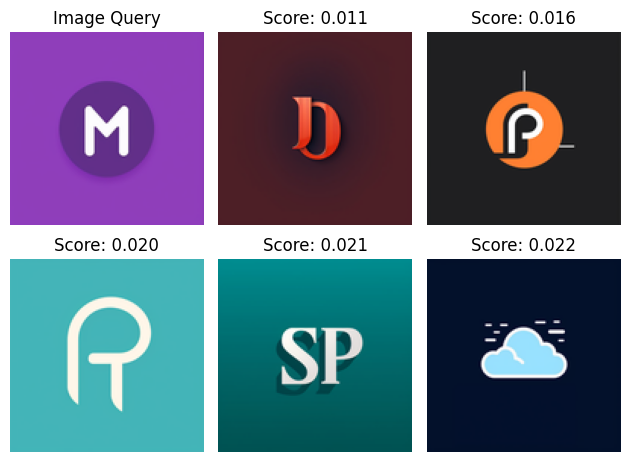

In [ ]:
index = 992 #0-319470
query_image = ds_test_with_embeddings[index]['image']

scores, retrieved_examples = pipeline(query_image=query_image,
                                      ploting=True
                                      )

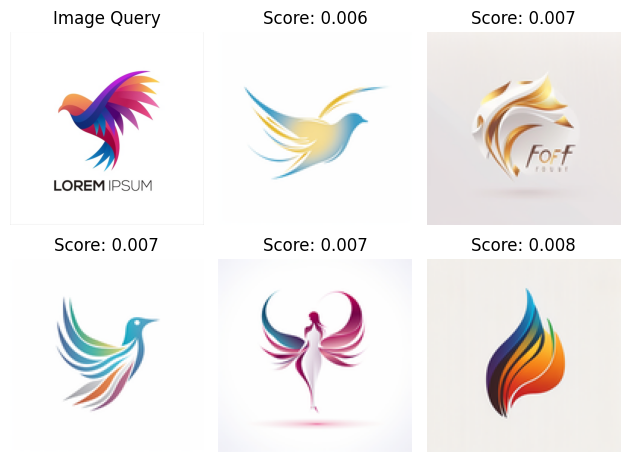

In [ ]:
query_image = "https://img.freepik.com/free-vector/bird-colorful-logo-gradient-vector_343694-1365.jpg"
scores, retrieved_examples = pipeline(query_image=query_image,
                                      ploting=True
                                      )